In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import statistics

years = range(2019,2025)

graphs = {}
returns = {}

base_modes = "../../data/02_clean"
k = 1

for year in years:
    file_path = f"../../data/04_graphs/{year}_{k}/graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{year}"] = pickle.load(f)
                
        returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year}.parquet")
        returns[year] = np.log(1 + returns[year])

In [9]:
import numpy as np
import networkx as nx
from sklearn.decomposition import PCA

def calculate_hybrid_risk_metric(G, use_pca=True, custom_weights=None):
    nodes = list(G.nodes)
    G = G.copy()
    
    for u, v, d in G.edges(data=True):
        # Euclidean distance transformation bounded between 0 and sqrt(2)
        d["distance"] = np.sqrt(2 * max(0.0, 1 - d["weight"]))
    
    # 1. Calculate raw metrics
    degree_dict = dict(nx.degree(G, weight="weight"))
    closeness_dict = nx.closeness_centrality(G, distance="distance")
    eig_dict = nx.eigenvector_centrality_numpy(G, weight="weight")
    
    # Betweenness is calculated but not included in the hybrid metric per your thesis text
    # betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    
    # 2. Standardize metrics using Z-scoring (mean=0, std=1)
    def standardize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        mean_val = vals.mean()
        std_val = vals.std()
        
        if std_val == 0:
            return {k: 0.0 for k in d.keys()}
            
        z_scores = {k: (v - mean_val) / std_val for k, v in d.items()}
        
        if invert:
            z_scores = {k: -v for k, v in z_scores.items()}
            
        return z_scores

    norm_degree = standardize_dict(degree_dict, invert=False)
    norm_closeness = standardize_dict(closeness_dict, invert=False)
    norm_eig = standardize_dict(eig_dict, invert=False)
    
    # 3. Determine Weights
    if use_pca:
        # Build feature matrix (N nodes x 3 metrics)
        features = np.array([
            [norm_degree[n], norm_closeness[n], norm_eig[n]] for n in nodes
        ])
        
        # Extract the First Principal Component
        pca = PCA(n_components=1)
        pca.fit(features)
        pc1_loadings = pca.components_[0]
        
        # PCA vectors can point in arbitrary directions. We take the absolute value
        # to ensure positive loadings, maintaining the logical direction of centrality.
        pc1_loadings = np.abs(pc1_loadings)
        
        # Normalize to sum to 1 (convex combination)
        pca_weights = pc1_loadings / np.sum(pc1_loadings)
        
        weights = {
            'degree': pca_weights[0],
            'closeness': pca_weights[1],
            'eigenvector': pca_weights[2]
        }
    else:
        # Fallback to custom or equal weights if PCA is disabled
        weights = custom_weights if custom_weights else {
            'degree': 1/3, 'closeness': 1/3, 'eigenvector': 1/3
        }

    # 4. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['closeness'] * norm_closeness[node] +
            weights['eigenvector'] * norm_eig[node] 
        )
        risk_scores[node] = score
    
    return risk_scores, weights

In [10]:
risk_scores = {}
for year in years:
    print(f"Computing risk scores for {year}...")
    # Add [0] here to grab only the risk_scores dictionary
    risk_scores[year] = calculate_hybrid_risk_metric(graphs[f"graph_{year}"])[0]

# The rest of your code will now work perfectly
df_long = pd.DataFrame([
    {"year": year, "stock": stock, "risk": score}
    for year, scores in risk_scores.items()
    for stock, score in scores.items()
])

Computing risk scores for 2019...
Computing risk scores for 2020...
Computing risk scores for 2021...
Computing risk scores for 2022...
Computing risk scores for 2023...
Computing risk scores for 2024...


In [11]:
# ============================================================
# 2. SUMMARY STATISTICS TABLE
# ============================================================
summary_rows = []
for year in years:
    scores = np.array(list(risk_scores[year].values()))
    summary_rows.append({
        "Year":    year,
        "Mean":    scores.mean(),
        "Median":  np.median(scores),
        "Std":     scores.std(),
        "Skew":    pd.Series(scores).skew(),
        "Kurt":    pd.Series(scores).kurt(),
        "Min":     scores.min(),
        "Max":     scores.max(),
        "Q25":     np.percentile(scores, 25),
        "Q75":     np.percentile(scores, 75),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Year").round(4)
print(summary_df.to_string())
# print("\nLaTeX:\n", summary_df.to_latex())

      Mean  Median     Std    Skew     Kurt     Min     Max     Q25     Q75
Year                                                                       
2019  -0.0 -0.0966  0.9082  4.7902  36.9167 -1.1524  9.2163 -0.5365  0.2448
2020  -0.0 -0.1782  0.9123  4.6623  37.0289 -1.1430  9.6269 -0.4925  0.2649
2021   0.0 -0.1859  0.8805  3.7419  22.3928 -1.1456  7.6063 -0.5009  0.1915
2022   0.0 -0.1416  0.9230  4.6460  33.0382 -1.0774  8.4952 -0.5063  0.1935
2023  -0.0 -0.1100  0.9068  4.3754  28.4720 -1.1045  8.2558 -0.4968  0.1444
2024   0.0 -0.1561  0.9089  4.0387  24.3130 -1.2103  7.5083 -0.5139  0.2418


In [12]:
centralities = ["central", "peripheral"]
portfolios = {}

for year in years:
    for centrality in centralities:
        cols = pd.read_csv(f"../../data/06_portfolios/{centrality}_{year}.csv", index_col="Date").columns.tolist()
        try:
            portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_{year-k}_{year}.parquet")[cols]
        except:
            portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_{year-k+1}_{year}.parquet")[cols]

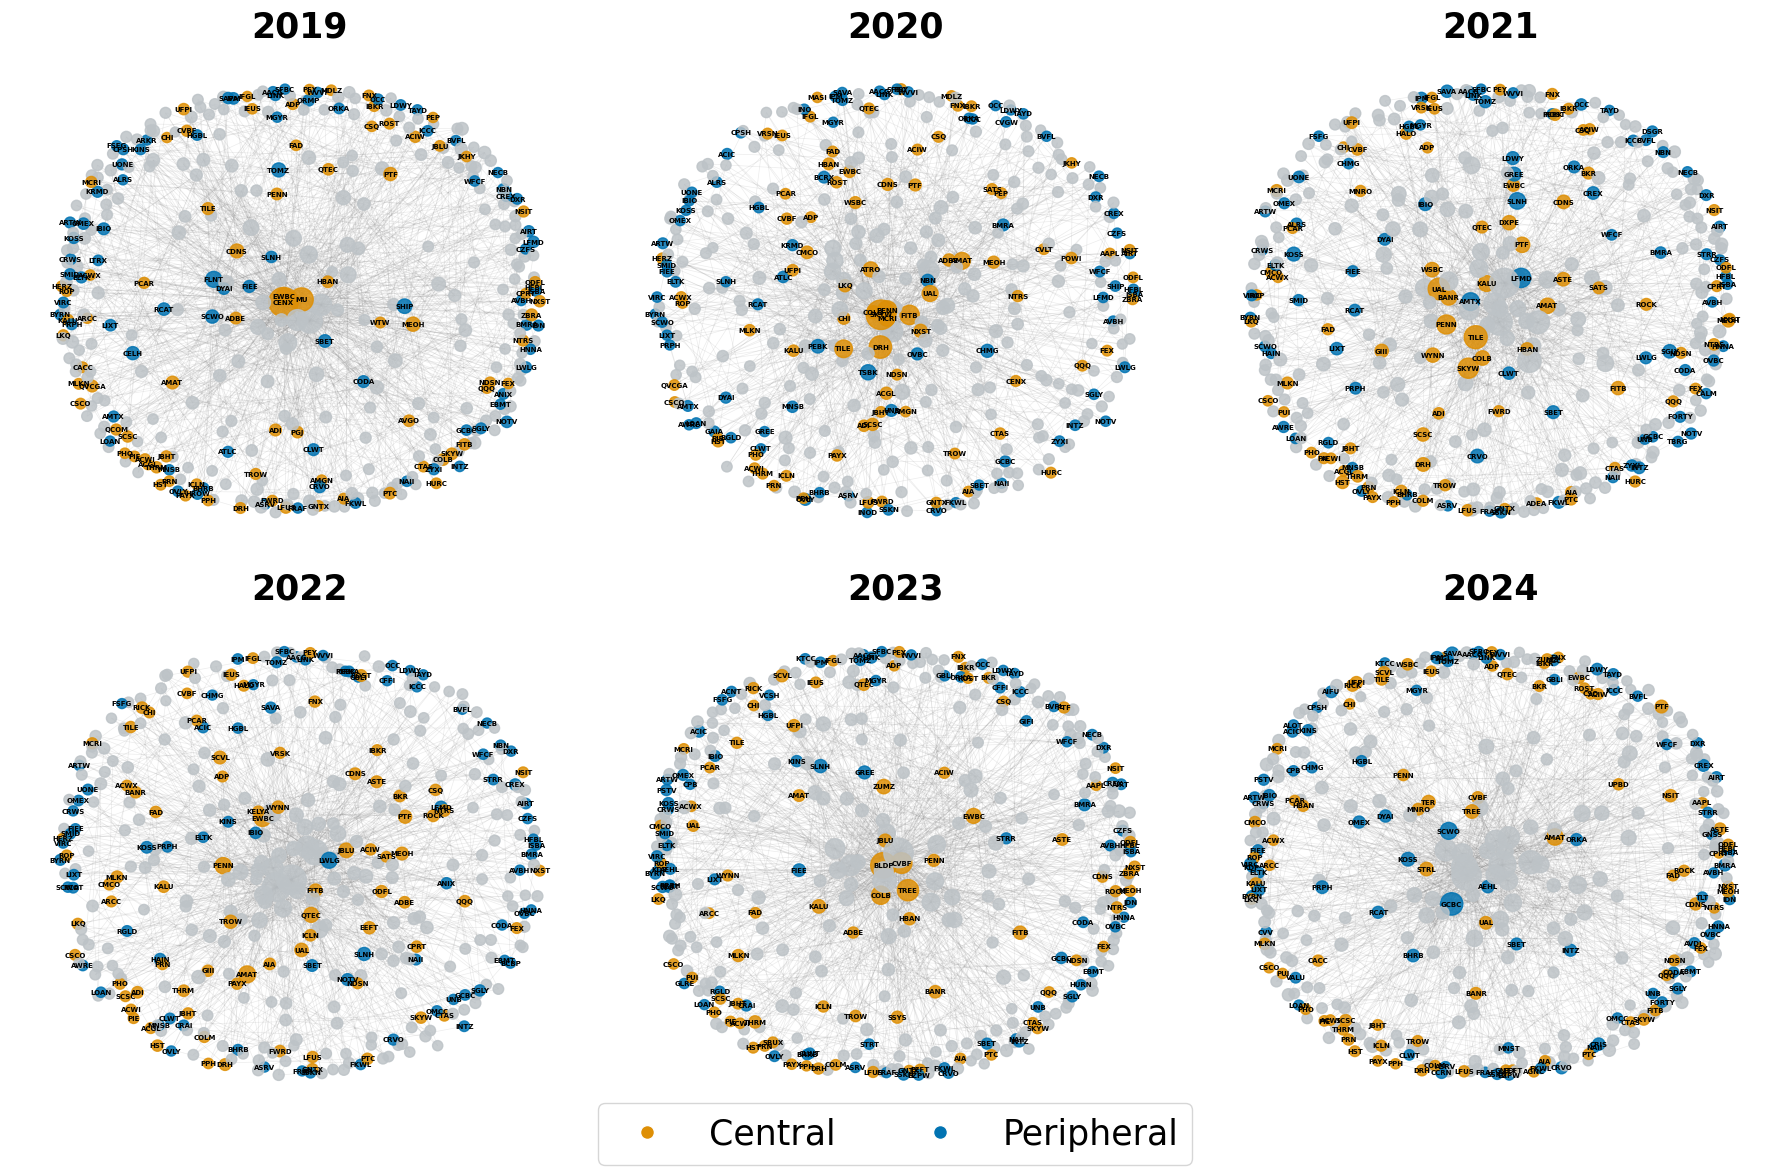

In [13]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, year in zip(axes.flat, years):
    G = graphs[f"graph_{year}"]
    
    # Get portfolio membership for this year
    central_tickers    = set(portfolios[f"central_{year}"].columns)
    peripheral_tickers = set(portfolios[f"peripheral_{year}"].columns)

    palette = sns.color_palette("colorblind")

    central_color = palette[1]
    peripheral_color = palette[0]
    middle_color = "#BDC3C7"
    
    # Assign colors
    node_colors = []
    for node in G.nodes():
        if node in central_tickers:
            node_colors.append(central_color)       # red  = high risk / central
        elif node in peripheral_tickers:
            node_colors.append(peripheral_color)       # green = low risk / peripheral
        else:
            node_colors.append(middle_color)       # grey = middle

    node_sizes = []
    degree = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    for node in G.nodes():
        node_sizes.append(50 + 400 * (degree[node] / max_deg))  # scale by weighted degree

    # Layout — spring layout seeded for reproducibility
    pos = nx.spring_layout(G, seed=42, k=0.4)

    # Draw edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.85)

    # Labels only for central/peripheral nodes to avoid clutter
    labels = {n: n for n in G.nodes() if n in central_tickers | peripheral_tickers}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=25, fontweight="bold")
    ax.axis("off")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=central_color, markersize=10, label="Central"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=peripheral_color, markersize=10, label="Peripheral"),
    # Line2D([0], [0], marker="o", color="w", markerfacecolor="#BDC3C7", markersize=10, label="Middle"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=25,
           bbox_to_anchor=(0.5, 0.01), frameon=True)

# fig.suptitle("TMFG Network by Year — Central vs Peripheral Stocks", fontsize=16, fontweight="bold")
os.makedirs(f"../../figures/window_{k}", exist_ok=True)
plt.savefig(f"../../figures/window_{k}/graphs.png", dpi=300)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()